In [2]:
import pandas as pd

file_path = "../data/processed/customer_transactions_clean.csv"

df_customer = pd.read_csv(file_path)

df_customer["InvoiceDate"] = pd.to_datetime(df_customer["InvoiceDate"])

df_customer.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Is_Cancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,False,20.34


In [3]:
customer_basic = (
    df_customer
    .groupby("CustomerID")
    .agg(
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("Revenue", "sum")
    )
    .reset_index()
)

customer_basic.head()

,CustomerID,Total_Orders,Total_Quantity,Total_Revenue
0,12346.0,1,74215,77183.60
1,12347.0,7,2458,4310.00
2,12348.0,4,2341,1797.24
3,12349.0,1,631,1757.55
4,12350.0,1,197,334.40


In [4]:
customer_summary = pd.DataFrame({
    "Metric": [
        "Unique Customers",
        "Customer Rows",
        "Duplicate CustomerIDs"
    ],
    "Value": [
        customer_basic["CustomerID"].nunique(),
        len(customer_basic),
        customer_basic["CustomerID"].duplicated().sum()
    ]
})

customer_summary

,Metric,Value
0,Unique Customers,4338
1,Customer Rows,4338
2,Duplicate CustomerIDs,0


In [5]:
customer_basic["Average_Order_Value"] = (
    customer_basic["Total_Revenue"]
    / customer_basic["Total_Orders"]
)

customer_basic["Average_Quantity_per_Order"] = (
    customer_basic["Total_Quantity"]
    / customer_basic["Total_Orders"]
)

customer_basic.head()

,CustomerID,Total_Orders,Total_Quantity,Total_Revenue,Average_Order_Value,Average_Quantity_per_Order
0,12346.0,1,74215,77183.60,77183.600000,74215.000000
1,12347.0,7,2458,4310.00,615.714286,351.142857
2,12348.0,4,2341,1797.24,449.310000,585.250000
3,12349.0,1,631,1757.55,1757.550000,631.000000
4,12350.0,1,197,334.40,334.400000,197.000000


In [6]:
customer_basic[
    [
        "Total_Orders",
        "Total_Quantity",
        "Total_Revenue",
        "Average_Order_Value",
        "Average_Quantity_per_Order"
    ]
].describe()

,Total_Orders,Total_Quantity,Total_Revenue,Average_Order_Value,Average_Quantity_per_Order
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,4.272015,1187.644537,2048.688081,417.645735,252.462892
std,7.697998,5043.619654,8985.230220,1796.511343,1312.769337
min,1.000000,1.000000,3.750000,3.450000,1.000000
25%,1.000000,159.000000,306.482500,177.867083,92.000000
50%,2.000000,378.000000,668.570000,291.940000,161.000000
75%,5.000000,989.750000,1660.597500,428.280625,270.000000
max,209.000000,196915.000000,280206.020000,84236.250000,74215.000000


In [7]:
reference_date = df_customer["InvoiceDate"].max() + pd.Timedelta(days=1)

customer_recency = (
    df_customer
    .groupby("CustomerID")["InvoiceDate"]
    .max()
    .reset_index()
)

customer_recency["Recency"] = (
    reference_date - customer_recency["InvoiceDate"]
).dt.days

customer_recency.head()

,CustomerID,InvoiceDate,Recency
0,12346.0,2011-01-18 10:01:00,326
1,12347.0,2011-12-07 15:52:00,2
2,12348.0,2011-09-25 13:13:00,75
3,12349.0,2011-11-21 09:51:00,19
4,12350.0,2011-02-02 16:01:00,310


In [8]:
customer_recency["Recency"].describe()

count    4338.000000
mean       92.536422
std       100.014169
min         1.000000
25%        18.000000
50%        51.000000
75%       142.000000
max       374.000000
Name: Recency, dtype: float64

In [9]:
rfm = (
    customer_recency[["CustomerID", "Recency"]]
    .merge(
        customer_basic[
            ["CustomerID", "Total_Orders", "Total_Revenue"]
        ],
        on="CustomerID",
        how="inner"
    )
)

rfm.head()

,CustomerID,Recency,Total_Orders,Total_Revenue
0,12346.0,326,1,77183.60
1,12347.0,2,7,4310.00
2,12348.0,75,4,1797.24
3,12349.0,19,1,1757.55
4,12350.0,310,1,334.40


In [10]:
rfm.shape

(4338, 4)

In [11]:
print("RFM shape:", rfm.shape)
print("Missing values:")
print(rfm.isna().sum())


RFM shape: (4338, 4)
Missing values:
CustomerID       0
Recency          0
Total_Orders     0
Total_Revenue    0
dtype: int64


In [12]:
customer_product_diversity = (
    df_customer
    .groupby("CustomerID")["StockCode"]
    .nunique()
    .reset_index(name="Unique_Products")
)

customer_product_diversity.head()

,CustomerID,Unique_Products
0,12346.0,1
1,12347.0,103
2,12348.0,22
3,12349.0,73
4,12350.0,17


In [13]:
rfm = rfm.merge(
    customer_product_diversity,
    on="CustomerID",
    how="left"
)

rfm.head()

,CustomerID,Recency,Total_Orders,Total_Revenue,Unique_Products
0,12346.0,326,1,77183.60,1
1,12347.0,2,7,4310.00,103
2,12348.0,75,4,1797.24,22
3,12349.0,19,1,1757.55,73
4,12350.0,310,1,334.40,17


In [14]:
rfm["Avg_Items_per_Order"] = (
    customer_basic["Total_Quantity"].values
    / customer_basic["Total_Orders"].values
)

rfm.head()


,CustomerID,Recency,Total_Orders,Total_Revenue,Unique_Products,Avg_Items_per_Order
0,12346.0,326,1,77183.60,1,74215.000000
1,12347.0,2,7,4310.00,103,351.142857
2,12348.0,75,4,1797.24,22,585.250000
3,12349.0,19,1,1757.55,73,631.000000
4,12350.0,310,1,334.40,17,197.000000


In [15]:
rfm["Avg_Items_per_Order"].describe()

count     4338.000000
mean       252.462892
std       1312.769337
min          1.000000
25%         92.000000
50%        161.000000
75%        270.000000
max      74215.000000
Name: Avg_Items_per_Order, dtype: float64

In [16]:
customer_active_period = (
    df_customer
    .groupby("CustomerID")["InvoiceDate"]
    .agg(["min", "max"])
    .reset_index()
)

customer_active_period["Active_Days"] = (
    customer_active_period["max"]
    - customer_active_period["min"]
).dt.days

customer_active_period.head()

,CustomerID,min,max,Active_Days
0,12346.0,2011-01-18 10:01:00,2011-01-18 10:01:00,0
1,12347.0,2010-12-07 14:57:00,2011-12-07 15:52:00,365
2,12348.0,2010-12-16 19:09:00,2011-09-25 13:13:00,282
3,12349.0,2011-11-21 09:51:00,2011-11-21 09:51:00,0
4,12350.0,2011-02-02 16:01:00,2011-02-02 16:01:00,0


In [17]:
customer_active_period["Active_Days"].describe()

count    4338.000000
mean      130.448594
std       132.039554
min         0.000000
25%         0.000000
50%        92.500000
75%       251.750000
max       373.000000
Name: Active_Days, dtype: float64

In [18]:
rfm = rfm.merge(
    customer_active_period[["CustomerID", "Active_Days"]],
    on="CustomerID",
    how="left"
)


rfm.head()

,CustomerID,Recency,Total_Orders,Total_Revenue,Unique_Products,Avg_Items_per_Order,Active_Days
0,12346.0,326,1,77183.60,1,74215.000000,0
1,12347.0,2,7,4310.00,103,351.142857,365
2,12348.0,75,4,1797.24,22,585.250000,282
3,12349.0,19,1,1757.55,73,631.000000,0
4,12350.0,310,1,334.40,17,197.000000,0


In [19]:
rfm.shape
rfm.isna().sum()

CustomerID             0
Recency                0
Total_Orders           0
Total_Revenue          0
Unique_Products        0
Avg_Items_per_Order    0
Active_Days            0
dtype: int64

In [20]:
rfm.describe()

,CustomerID,Recency,Total_Orders,Total_Revenue,Unique_Products,Avg_Items_per_Order,Active_Days
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081,61.501153,252.462892,130.448594
std,1721.808492,100.014169,7.697998,8985.230220,85.366768,1312.769337,132.039554
min,12346.000000,1.000000,1.000000,3.750000,1.000000,1.000000,0.000000
25%,13813.250000,18.000000,1.000000,306.482500,16.000000,92.000000,0.000000
50%,15299.500000,51.000000,2.000000,668.570000,35.000000,161.000000,92.500000
75%,16778.750000,142.000000,5.000000,1660.597500,77.000000,270.000000,251.750000
max,18287.000000,374.000000,209.000000,280206.020000,1787.000000,74215.000000,373.000000


In [21]:
rfm.info()

<class 'pandas.DataFrame'>
RangeIndex: 4338 entries, 0 to 4337
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           4338 non-null   float64
 1   Recency              4338 non-null   int64  
 2   Total_Orders         4338 non-null   int64  
 3   Total_Revenue        4338 non-null   float64
 4   Unique_Products      4338 non-null   int64  
 5   Avg_Items_per_Order  4338 non-null   float64
 6   Active_Days          4338 non-null   int64  
dtypes: float64(3), int64(4)
memory usage: 237.4 KB


In [22]:
rfm.isna().sum()

CustomerID             0
Recency                0
Total_Orders           0
Total_Revenue          0
Unique_Products        0
Avg_Items_per_Order    0
Active_Days            0
dtype: int64

In [23]:
rfm.shape

(4338, 7)

In [24]:
rfm.drop(columns=["CustomerID"]).corr().round(2)

,Recency,Total_Orders,Total_Revenue,Unique_Products,Avg_Items_per_Order,Active_Days
Recency,1.00,-0.26,-0.12,-0.30,0.01,-0.51
Total_Orders,-0.26,1.00,0.55,0.69,0.01,0.48
Total_Revenue,-0.12,0.55,1.00,0.39,0.31,0.23
Unique_Products,-0.30,0.69,0.39,1.00,0.02,0.46
Avg_Items_per_Order,0.01,0.01,0.31,0.02,1.00,0.00
Active_Days,-0.51,0.48,0.23,0.46,0.00,1.00


In [25]:
rfm.drop(columns=["CustomerID"]).skew().sort_values(ascending=False)

Avg_Items_per_Order    48.008243
Total_Revenue          19.339368
Total_Orders           12.067031
Unique_Products         6.919445
Recency                 1.246048
Active_Days             0.454675
dtype: float64

In [26]:
import numpy as np

In [27]:
rfm_model = rfm.copy()

log_features = [
    "Total_Orders",
    "Total_Revenue",
    "Unique_Products",
    "Avg_Items_per_Order",
    "Active_Days"
]

for col in log_features:
    rfm_model[f"Log_{col}"] = np.log1p(rfm_model[col])

In [28]:
rfm_model[
    [
        "Recency",
        "Log_Total_Orders",
        "Log_Total_Revenue",
        "Log_Unique_Products",
        "Log_Avg_Items_per_Order",
        "Log_Active_Days"
    ]
].describe()

,Recency,Log_Total_Orders,Log_Total_Revenue,Log_Unique_Products,Log_Avg_Items_per_Order,Log_Active_Days
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,92.536422,1.345582,6.588562,3.551564,5.040655,3.242536
std,100.014169,0.683104,1.258438,1.131560,0.903702,2.527555
min,1.000000,0.693147,1.558145,0.693147,0.693147,0.000000
25%,18.000000,0.693147,5.728418,2.833213,4.532599,0.000000
50%,51.000000,1.098612,6.506636,3.583519,5.087596,4.537947
75%,142.000000,1.791759,7.415535,4.356709,5.602119,5.532399
max,374.000000,5.347108,12.543284,7.488853,11.214735,5.924256


In [29]:
model_features = [
    "Recency",
    "Log_Total_Orders",
    "Log_Total_Revenue",
    "Log_Unique_Products",
    "Log_Avg_Items_per_Order",
    "Log_Active_Days"
]

X = rfm_model[model_features].copy()

X.head()

,Recency,Log_Total_Orders,Log_Total_Revenue,Log_Unique_Products,Log_Avg_Items_per_Order,Log_Active_Days
0,326,0.693147,11.253955,0.693147,11.214735,0.000000
1,2,2.079442,8.368925,4.644391,5.864037,5.902633
2,75,1.609438,7.494564,3.135494,6.373746,5.645447
3,19,0.693147,7.472245,4.304065,6.448889,0.000000
4,310,0.693147,5.815324,2.890372,5.288267,0.000000


In [30]:
X.shape

(4338, 6)

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [32]:
X_scaled.shape

(4338, 6)

In [33]:
X_scaled.mean(axis=0).round(2)


array([ 0., -0., -0.,  0.,  0., -0.])

In [34]:
X_scaled.std(axis=0).round(2)

array([1., 1., 1., 1., 1., 1.])

In [35]:
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

inertia

[15051.153811435846,
 12352.960904325959,
 10269.462324134398,
 9082.189476271164,
 8116.410372261153,
 7560.503259627183,
 7040.528544320875,
 6587.203371904949,
 6206.795226213395]

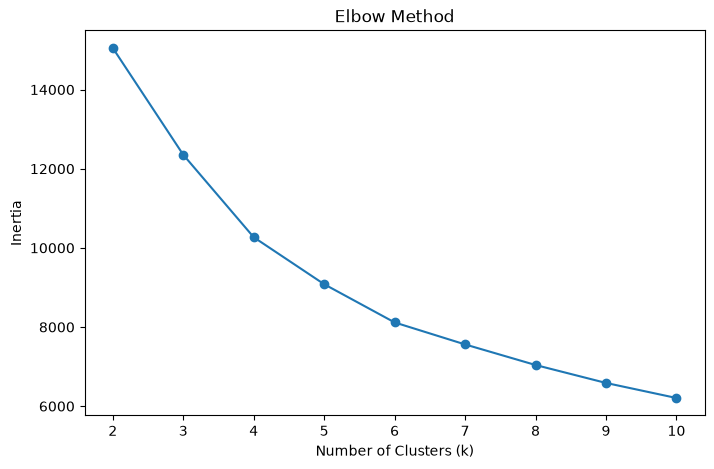

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [37]:
from sklearn.metrics import silhouette_score

silhouette_scores = {}

for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    silhouette_scores[k] = silhouette_score(
        X_scaled,
        labels
    )

silhouette_scores

{2: 0.3755514264629875,
 3: 0.2724121915890533,
 4: 0.2769302363053526,
 5: 0.2809914389456929,
 6: 0.25441401301273925}

In [38]:
cluster_sizes = {}

for k in range(2, 6):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    cluster_sizes[k] = pd.Series(labels).value_counts().sort_index().to_dict()

cluster_sizes

{2: {0: 1976, 1: 2362},
 3: {0: 1641, 1: 1146, 2: 1551},
 4: {0: 1525, 1: 1112, 2: 915, 3: 786},
 5: {0: 581, 1: 1502, 2: 445, 3: 1075, 4: 735}}

In [39]:
cluster_profiles = {}

for k in [3, 4, 5]:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    temp = rfm.copy()
    temp["Cluster"] = labels
    
    profile = (
        temp
        .groupby("Cluster")
        .agg(
            Customers=("CustomerID", "count"),
            Avg_Recency=("Recency", "mean"),
            Avg_Orders=("Total_Orders", "mean"),
            Avg_Revenue=("Total_Revenue", "mean"),
            Avg_Products=("Unique_Products", "mean"),
            Avg_Items_per_Order=("Avg_Items_per_Order", "mean"),
            Avg_Active_Days=("Active_Days", "mean")
        )
        .round(2)
    )
    
    cluster_profiles[k] = profile

cluster_profiles


{3:          Customers  Avg_Recency  Avg_Orders  Avg_Revenue  Avg_Products  \
 Cluster                                                                  
 0             1641       160.81        1.11       372.96         20.87   
 1             1146        30.07       10.40      6109.64        142.41   
 2             1551        66.45        3.09       821.10         44.71   
 
          Avg_Items_per_Order  Avg_Active_Days  
 Cluster                                        
 0                     199.43             2.40  
 1                     436.64           267.15  
 2                     172.49           164.92  ,
 4:          Customers  Avg_Recency  Avg_Orders  Avg_Revenue  Avg_Products  \
 Cluster                                                                  
 0             1525        64.44        3.14       839.97         45.44   
 1             1112        28.84       10.59      6149.48        144.18   
 2              915        91.13        1.08       598.36         29.27

In [40]:
for k in [3, 4, 5]:
    sizes = list(cluster_sizes[k].values())
    
    print(
        f"K={k} | "
        f"Silhouette={silhouette_scores[k]:.3f} | "
        f"Smallest cluster={min(sizes)} | "
        f"Largest cluster={max(sizes)}"
    )

K=3 | Silhouette=0.272 | Smallest cluster=1146 | Largest cluster=1641
K=4 | Silhouette=0.277 | Smallest cluster=786 | Largest cluster=1525
K=5 | Silhouette=0.281 | Smallest cluster=445 | Largest cluster=1502


In [41]:
final_k = 4

final_kmeans = KMeans(
    n_clusters=final_k,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = final_kmeans.fit_predict(X_scaled)

In [42]:
rfm["Cluster"].value_counts().sort_index()

Cluster
0    1525
1    1112
2     915
3     786
Name: count, dtype: int64

In [43]:
rfm.head()

,CustomerID,Recency,Total_Orders,Total_Revenue,Unique_Products,Avg_Items_per_Order,Active_Days,Cluster
0,12346.0,326,1,77183.60,1,74215.000000,0,2
1,12347.0,2,7,4310.00,103,351.142857,365,1
2,12348.0,75,4,1797.24,22,585.250000,282,0
3,12349.0,19,1,1757.55,73,631.000000,0,2
4,12350.0,310,1,334.40,17,197.000000,0,3


In [44]:
final_profile = (
    rfm
    .groupby("Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Revenue=("Total_Revenue", "mean"),
        Avg_Products=("Unique_Products", "mean"),
        Avg_Items_per_Order=("Avg_Items_per_Order", "mean"),
        Avg_Active_Days=("Active_Days", "mean")
    )
    .round(2)
)

final_profile

,Customers,Avg_Recency,Avg_Orders,Avg_Revenue,Avg_Products,Avg_Items_per_Order,Avg_Active_Days
Cluster,,,,,,,
0,1525,64.44,3.14,839.97,45.44,170.33,169.53
1,1112,28.84,10.59,6149.48,144.18,363.31,269.88
2,915,91.13,1.08,598.36,29.27,396.87,0.48
3,786,238.80,1.25,280.57,13.22,86.88,8.67


In [45]:
cluster_names = {
    0: "Regular / Mid-Value",
    1: "High-Value Loyal",
    2: "One-Time",
    3: "Inactive / At-Risk"
}

rfm["Segment"] = rfm["Cluster"].map(cluster_names)

rfm[["CustomerID", "Cluster", "Segment"]].head()

,CustomerID,Cluster,Segment
0,12346.0,2,One-Time
1,12347.0,1,High-Value Loyal
2,12348.0,0,Regular / Mid-Value
3,12349.0,2,One-Time
4,12350.0,3,Inactive / At-Risk


In [46]:
rfm["Segment"].value_counts()

Segment
Regular / Mid-Value    1525
High-Value Loyal       1112
One-Time                915
Inactive / At-Risk      786
Name: count, dtype: int64

In [47]:
segment_summary = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Revenue=("Total_Revenue", "sum"),
        Avg_Revenue=("Total_Revenue", "mean"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Recency=("Recency", "mean")
    )
    .reset_index()
)

segment_summary["Customer_Share_%"] = (
    segment_summary["Customers"]
    / segment_summary["Customers"].sum()
    * 100
).round(2)

segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Revenue"]
    / segment_summary["Total_Revenue"].sum()
    * 100
).round(2)

segment_summary.sort_values(
    "Revenue_Share_%",
    ascending=False
)

,Segment,Customers,Total_Revenue,Avg_Revenue,Avg_Orders,Avg_Recency,Customer_Share_%,Revenue_Share_%
0,High-Value Loyal,1112,6838220.961,6149.479281,10.592626,28.836331,25.63,76.94
3,Regular / Mid-Value,1525,1280961.212,839.974565,3.138361,64.441311,35.15,14.41
2,One-Time,915,547500.031,598.360690,1.076503,91.130055,21.09,6.16
1,Inactive / At-Risk,786,220526.690,280.568308,1.249364,238.804071,18.12,2.48


In [48]:
print("Customers:", rfm["CustomerID"].nunique())
print("Rows:", len(rfm))
print("Missing values:")
print(rfm.isna().sum())
print("\nDuplicate CustomerIDs:", rfm["CustomerID"].duplicated().sum())
print("\nSegments:")
print(rfm["Segment"].value_counts())

Customers: 4338
Rows: 4338
Missing values:
CustomerID             0
Recency                0
Total_Orders           0
Total_Revenue          0
Unique_Products        0
Avg_Items_per_Order    0
Active_Days            0
Cluster                0
Segment                0
dtype: int64

Duplicate CustomerIDs: 0

Segments:
Segment
Regular / Mid-Value    1525
High-Value Loyal       1112
One-Time                915
Inactive / At-Risk      786
Name: count, dtype: int64


In [49]:
output_path = "../data/processed/customer_segmentation_final.csv"

rfm.to_csv(
    output_path,
    index=False
)

print(f"Saved: {output_path}")

Saved: ../data/processed/customer_segmentation_final.csv


In [50]:
check = pd.read_csv(output_path)

print(check.shape)
print(check.columns.tolist())


(4338, 9)
['CustomerID', 'Recency', 'Total_Orders', 'Total_Revenue', 'Unique_Products', 'Avg_Items_per_Order', 'Active_Days', 'Cluster', 'Segment']


In [51]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(
    X_scaled,
    rfm["Cluster"]
)

print("Final K=4 Silhouette Score:", round(final_silhouette, 4))

Final K=4 Silhouette Score: 0.2769


In [52]:
from sklearn.metrics import silhouette_samples
import pandas as pd

sample_silhouette_values = silhouette_samples(
    X_scaled,
    rfm["Cluster"]
)

cluster_silhouette = (
    pd.DataFrame({
        "Cluster": rfm["Cluster"],
        "Silhouette": sample_silhouette_values
    })
    .groupby("Cluster")["Silhouette"]
    .agg(["mean", "min", "max", "count"])
    .round(4)
)

cluster_silhouette

,mean,min,max,count
Cluster,,,,
0,0.2770,0.0027,0.4990,1525
1,0.2908,-0.0133,0.5031,1112
2,0.3231,-0.0330,0.5094,915
3,0.2034,-0.1138,0.4382,786


In [53]:
segment_validation = (
    rfm
    .groupby(["Cluster", "Segment"])
    .agg(
        Customers=("CustomerID", "count")
    )
    .reset_index()
)

segment_validation["Customer_Share"] = (
    segment_validation["Customers"]
    / len(rfm)
    * 100
)

segment_validation.round(2)

,Cluster,Segment,Customers,Customer_Share
0,0,Regular / Mid-Value,1525,35.15
1,1,High-Value Loyal,1112,25.63
2,2,One-Time,915,21.09
3,3,Inactive / At-Risk,786,18.12


In [54]:
validation_profile = (
    rfm
    .groupby(["Cluster", "Segment"])
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Revenue=("Total_Revenue", "mean"),
        Avg_Products=("Unique_Products", "mean"),
        Avg_Active_Days=("Active_Days", "mean")
    )
    .round(2)
    .sort_values("Avg_Revenue", ascending=False)
)

validation_profile


,,Customers,Avg_Recency,Avg_Orders,Avg_Revenue,Avg_Products,Avg_Active_Days
Cluster,Segment,,,,,,
1,High-Value Loyal,1112,28.84,10.59,6149.48,144.18,269.88
0,Regular / Mid-Value,1525,64.44,3.14,839.97,45.44,169.53
2,One-Time,915,91.13,1.08,598.36,29.27,0.48
3,Inactive / At-Risk,786,238.80,1.25,280.57,13.22,8.67


## Segmentation Validation

The final K=4 segmentation was validated using cluster separation, segment size, and business-profile consistency.

### Validation dimensions

- The overall silhouette score was checked for the final K=4 model.
- Individual cluster silhouette scores were reviewed to identify poorly separated groups.
- Segment sizes were checked to ensure that no cluster was excessively small or dominant.
- Segment-level averages for Recency, Orders, Revenue, Product Diversity, and Active Days were compared.

### Business validation

The four segments show distinct behavioral profiles:

- **High-Value Loyal:** recent activity, high order frequency, high revenue, broad product diversity, and long active periods.
- **Regular / Mid-Value:** moderate recency, repeat purchasing behavior, moderate revenue, and meaningful product diversity.
- **One-Time:** low order frequency and short active periods, with limited repeat-purchase evidence.
- **Inactive / At-Risk:** substantially higher recency and low engagement compared with the active segments.

These differences provide behavioral evidence supporting the practical interpretation of the four customer segments.

In [55]:
import pandas as pd

file_path = "../data/processed/customer_segmentation_final.csv"

rfm = pd.read_csv(file_path)

rfm["Avg_Order_Value"] = (
    rfm["Total_Revenue"] / rfm["Total_Orders"]
)

print(rfm.shape)
rfm.head()

(4338, 10)


,CustomerID,Recency,Total_Orders,Total_Revenue,Unique_Products,Avg_Items_per_Order,Active_Days,Cluster,Segment,Avg_Order_Value
0,12346.0,326,1,77183.60,1,74215.000000,0,2,One-Time,77183.600000
1,12347.0,2,7,4310.00,103,351.142857,365,1,High-Value Loyal,615.714286
2,12348.0,75,4,1797.24,22,585.250000,282,0,Regular / Mid-Value,449.310000
3,12349.0,19,1,1757.55,73,631.000000,0,2,One-Time,1757.550000
4,12350.0,310,1,334.40,17,197.000000,0,3,Inactive / At-Risk,334.400000


In [56]:
cluster_profile = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Avg_Recency=("Recency", "mean"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Revenue=("Total_Revenue", "mean"),
        Avg_Order_Value=("Avg_Order_Value", "mean"),
        Avg_Products=("Unique_Products", "mean"),
        Avg_Active_Days=("Active_Days", "mean")
    )
    .round(2)
    .sort_values("Avg_Revenue", ascending=False)
)

cluster_profile


,Customers,Avg_Recency,Avg_Orders,Avg_Revenue,Avg_Order_Value,Avg_Products,Avg_Active_Days
Segment,,,,,,,
High-Value Loyal,1112,28.84,10.59,6149.48,627.14,144.18,269.88
Regular / Mid-Value,1525,64.44,3.14,839.97,285.55,45.44,169.53
One-Time,915,91.13,1.08,598.36,560.36,29.27,0.48
Inactive / At-Risk,786,238.80,1.25,280.57,211.42,13.22,8.67


### High-Value Loyal

**Evidence**
- 1,112 customers
- Average Recency: 28.84 days
- Average Orders: 10.59
- Average Revenue: £6,149.48
- Average Order Value: £627.14
- Average Unique Products: 144.18
- Average Active Days: 269.88

**Behavioral Interpretation**

These customers purchase relatively recently, place orders frequently, generate substantially higher revenue, and show broad product engagement over a long active period.

**Business Interpretation**

This segment represents the strongest observed customer-value group in the dataset and shows sustained engagement rather than isolated purchasing activity.

### Regular / Mid-Value

**Evidence**
- 1,525 customers
- Average Recency: 64.44 days
- Average Orders: 3.14
- Average Revenue: £839.97
- Average Order Value: £285.55
- Average Unique Products: 45.44
- Average Active Days: 169.53

**Behavioral Interpretation**

These customers show repeat purchasing behavior with moderate order frequency, revenue, product diversity, and customer activity duration.

**Business Interpretation**

This segment represents the largest customer group and demonstrates established but lower-value engagement compared with the High-Value Loyal segment.

In [57]:
segment_comparison = (
    rfm
    .groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Customer_Share=("CustomerID", lambda x: len(x) / len(rfm) * 100),
        Avg_Recency=("Recency", "mean"),
        Avg_Orders=("Total_Orders", "mean"),
        Avg_Revenue=("Total_Revenue", "mean"),
        Avg_Order_Value=("Avg_Order_Value", "mean"),
        Avg_Products=("Unique_Products", "mean"),
        Avg_Active_Days=("Active_Days", "mean")
    )
    .round(2)
    .sort_values("Avg_Revenue", ascending=False)
)

segment_comparison

,Customers,Customer_Share,Avg_Recency,Avg_Orders,Avg_Revenue,Avg_Order_Value,Avg_Products,Avg_Active_Days
Segment,,,,,,,,
High-Value Loyal,1112,25.63,28.84,10.59,6149.48,627.14,144.18,269.88
Regular / Mid-Value,1525,35.15,64.44,3.14,839.97,285.55,45.44,169.53
One-Time,915,21.09,91.13,1.08,598.36,560.36,29.27,0.48
Inactive / At-Risk,786,18.12,238.80,1.25,280.57,211.42,13.22,8.67


In [58]:
segment_comparison.to_csv(
    "../data/processed/segment_comparison.csv",
    index=True
)

print("Segment comparison saved successfully.")

Segment comparison saved successfully.


In [59]:
pd.read_csv(
    "../data/processed/segment_comparison.csv",
    index_col=0
)

,Customers,Customer_Share,Avg_Recency,Avg_Orders,Avg_Revenue,Avg_Order_Value,Avg_Products,Avg_Active_Days
Segment,,,,,,,,
High-Value Loyal,1112,25.63,28.84,10.59,6149.48,627.14,144.18,269.88
Regular / Mid-Value,1525,35.15,64.44,3.14,839.97,285.55,45.44,169.53
One-Time,915,21.09,91.13,1.08,598.36,560.36,29.27,0.48
Inactive / At-Risk,786,18.12,238.80,1.25,280.57,211.42,13.22,8.67


## Final Segment Interpretation

| Segment | Core Behavioral Pattern | Business Meaning |
|---|---|---|
| High-Value Loyal | Recent, frequent, high-revenue, broad product engagement | Highest observed customer-value group |
| Regular / Mid-Value | Repeat purchases with moderate engagement and revenue | Largest established customer group |
| One-Time | Very low repeat frequency and short active period | Limited observed repeat engagement |
| Inactive / At-Risk | Long recency and low engagement | Low current observed activity |

### Interpretation Principle

Segment names are descriptive labels based on observed customer behavior. They do not imply future outcomes with certainty. Business actions should therefore be based on the measurable differences in Recency, Orders, Revenue, Order Value, Product Diversity, and Active Days.